Modelos cargados correctamente.
Campaña seleccionada para predicción:
   campaign_id campaign_name        created_date         launch_date  \
0          258          Demo 2026-04-07 06:09:29 2026-04-07 06:07:00   

  campaign_status  
0     In progress  
Shape de la campaña: (1, 14)

PREDICCIONES PRINCIPALES PARA LA CAMPAÑA FUTURA

1. Distribución de patrones detectados:
pattern_credentials          1
pattern_validation           1
pattern_authority            0
pattern_urgency              0
pattern_threat               0
pattern_incentive            0
pattern_curiosity            0
pattern_corporate_context    0
dtype: int64

2. Distribución del riesgo derivado:
risk_label_rule
Medio    1
Name: count, dtype: int64

3. Distribución de la clase predicha de reporte:
pred_reported
0    1
Name: count, dtype: int64

4. Top 20 resultados más críticos según riesgo y probabilidad de reporte:
   result_id                        email  \
0      16461  edwin.e.ayala1997@gmail.com   

           

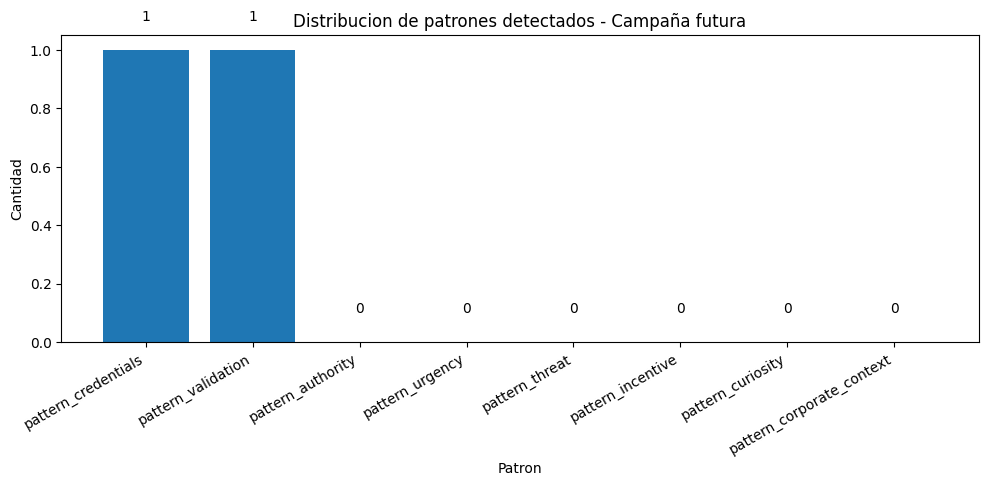

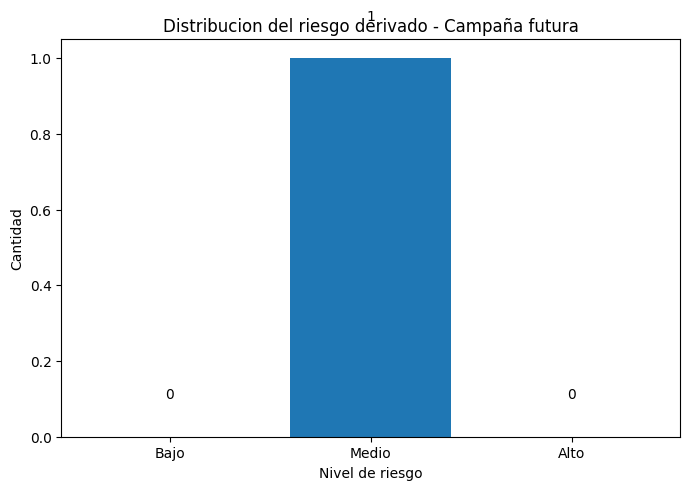

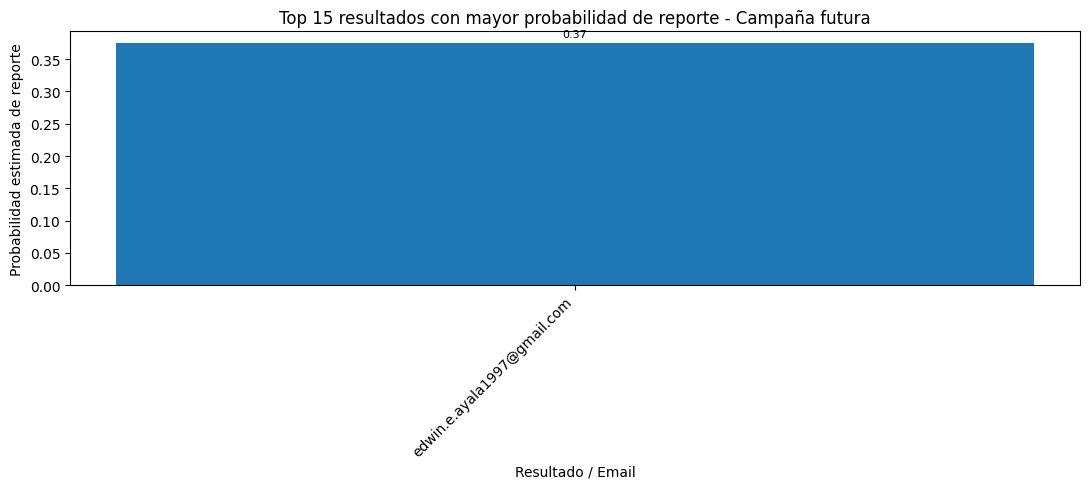


Shape de la tabla final de predicciones: (1, 20)


,result_id,campaign_id,campaign_name,email,position,template_subject,result_status,reported,risk_score,risk_label_rule,pred_reported,pred_reported_proba,pattern_urgency,pattern_authority,pattern_credentials,pattern_threat,pattern_validation,pattern_incentive,pattern_curiosity,pattern_corporate_context
0,16461,258,Demo,edwin.e.ayala1997@gmail.com,NA,Convocatoria abierta - CUBO_AI – Primera edici...,Submitted Data,0,4.5,Medio,0,0.374375,0,0,1,0,1,0,0,0


In [3]:
# =========================================================
# BLOQUE UNICO COMPLETO:
# ULTIMA CAMPAÑA + MODELOS + df_campaign_pred + 3 GRAFICAS
# =========================================================
# Este bloque:
# 1. crea la conexión a MySQL,
# 2. carga los modelos finales del proyecto,
# 3. consulta la última campaña de GoPhish,
# 4. construye `df_campaign_pred`,
# 5. y genera las 3 gráficas de predicción más importantes.
#
# Variables que quedan definidas dentro del mismo bloque:
# - engine
# - model_patterns_final
# - model_report_rf
# - pattern_cols
# - df_campaign
# - df_campaign_pred

# =========================================================
# 1. IMPORTACION DE DEPENDENCIAS
# =========================================================
# Este bloque importa las librerías necesarias para:
# - conectarse a MySQL,
# - cargar modelos serializados,
# - procesar datos,
# - y graficar resultados.

import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# =========================================================
# 2. CONFIGURACION DE CONEXION A MYSQL
# =========================================================
# Completa estos datos según tu entorno.

sys.path.append(os.path.abspath('..'))

# Importa dependencias necesarias para la siguiente fase del análisis.
from helpers.mysql_connections import create_mysql_engine


engine = create_mysql_engine()

# Define la carpeta donde guardaste los modelos finales.
MODELS_DIR = "exportables_finales_proyecto"

# Carga el modelo multietiqueta de patrones.
model_patterns_final = joblib.load(
    os.path.join(MODELS_DIR, "model_patterns_final.joblib")
)

# Carga el modelo final de reporte con Random Forest.
model_report_rf = joblib.load(
    os.path.join(MODELS_DIR, "model_report_rf.joblib")
)

print("Modelos cargados correctamente.")

# =========================================================
# 3. DEFINICION DE COLUMNAS DE PATRONES
# =========================================================

pattern_cols = [
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

# =========================================================
# 4. SELECCION DE CAMPAÑA FUTURA
# =========================================================
# Aquí se usa la campaña más reciente. Si quieres una campaña específica, cambia el WHERE.

q_future_campaign = """
SELECT
    c.id AS campaign_id,
    c.name AS campaign_name,
    c.created_date,
    c.launch_date,
    c.status AS campaign_status
FROM gophish.campaigns c
ORDER BY COALESCE(c.launch_date, c.created_date) DESC
LIMIT 1
"""

df_future_campaign = pd.read_sql(q_future_campaign, engine)

if df_future_campaign.empty:
    raise ValueError("No se encontró ninguna campaña en la base de datos.")

future_campaign_id = int(df_future_campaign.iloc[0]["campaign_id"])

print("Campaña seleccionada para predicción:")
print(df_future_campaign)

# =========================================================
# 5. EXTRAER LOS RESULTADOS DE LA CAMPAÑA
# =========================================================

q_future_data = f"""
SELECT
    r.id AS result_id,
    r.campaign_id,
    r.user_id,
    r.r_id,
    r.email,
    r.first_name,
    r.last_name,
    r.position,
    r.status AS result_status,
    r.reported,
    c.name AS campaign_name,
    c.template_id,
    t.subject AS template_subject,
    t.text AS template_text
FROM gophish.results r
LEFT JOIN gophish.campaigns c
    ON r.campaign_id = c.id
LEFT JOIN gophish.templates t
    ON c.template_id = t.id
WHERE r.campaign_id = {future_campaign_id}
"""

df_future = pd.read_sql(q_future_data, engine)

if df_future.empty:
    raise ValueError("La campaña seleccionada no tiene resultados asociados en results.")

print("Shape de la campaña:", df_future.shape)

# =========================================================
# 6. CONSTRUIR EL TEXTO COMPLETO
# =========================================================

df_future["text_full"] = (
    df_future["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_future["template_text"].fillna("").astype(str).str.strip()
).str.strip()

# =========================================================
# 7. PREDICCION DE PATRONES DE INGENIERIA SOCIAL
# =========================================================

pattern_pred = model_patterns_final.predict(df_future["text_full"])
df_patterns_pred = pd.DataFrame(pattern_pred, columns=pattern_cols)

df_future_pred = pd.concat(
    [df_future.reset_index(drop=True), df_patterns_pred],
    axis=1
)

# =========================================================
# 8. CONSTRUCCION DEL RIESGO DERIVADO
# =========================================================

df_future_pred["urgent_flag"] = df_future_pred["pattern_urgency"]
df_future_pred["url_flag"] = 0
df_future_pred["credentials_flag"] = df_future_pred["pattern_credentials"]

df_future_pred["risk_score"] = (
    2.0 * df_future_pred["pattern_threat"] +
    2.0 * df_future_pred["pattern_credentials"] +
    1.5 * df_future_pred["pattern_urgency"] +
    1.5 * df_future_pred["pattern_validation"] +
    1.0 * df_future_pred["pattern_authority"] +
    1.0 * df_future_pred["pattern_corporate_context"] +
    1.0 * df_future_pred["credentials_flag"] +
    0.5 * df_future_pred["url_flag"] +
    0.5 * df_future_pred["pattern_curiosity"] +
    0.5 * df_future_pred["pattern_incentive"]
)

def map_risk(score):
    if score <= 2.0:
        return 0
    elif score <= 5.0:
        return 1
    return 2

risk_label_map = {
    0: "Bajo",
    1: "Medio",
    2: "Alto"
}

df_future_pred["risk_target_rule"] = df_future_pred["risk_score"].apply(map_risk)
df_future_pred["risk_label_rule"] = df_future_pred["risk_target_rule"].map(risk_label_map)

# =========================================================
# 9. PREPARAR VARIABLES PARA PREDICCION DE REPORTE
# =========================================================

num_cols_report = [
    "urgent_flag",
    "url_flag",
    "credentials_flag",
    "risk_score",
    "risk_target_rule",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

cat_cols_report = [
    "position",
    "result_status",
    "context_detected",
    "subcontext_detected",
    "message_type_detected",
    "text_level_detected",
    "intention_detected",
    "action_required_detected",
    "risk_label_rule"
]

# Crea columnas categóricas faltantes si no existen.
for c in cat_cols_report:
    if c not in df_future_pred.columns:
        df_future_pred[c] = ""

# Limpia columnas categóricas.
for c in cat_cols_report:
    df_future_pred[c] = df_future_pred[c].fillna("").astype(str).str.strip()

# Crea columnas numéricas faltantes si no existen.
for c in num_cols_report:
    if c not in df_future_pred.columns:
        df_future_pred[c] = 0

# Limpia columnas numéricas.
for c in num_cols_report:
    df_future_pred[c] = pd.to_numeric(df_future_pred[c], errors="coerce").fillna(0)

X_future_report = df_future_pred[num_cols_report + cat_cols_report].copy()

# =========================================================
# 10. PREDICCION DE REPORTE
# =========================================================

df_future_pred["pred_reported"] = model_report_rf.predict(X_future_report)
df_future_pred["pred_reported_proba"] = model_report_rf.predict_proba(X_future_report)[:, 1]

# =========================================================
# 11. RESULTADOS PRINCIPALES DE PREDICCION
# =========================================================

print("\n" + "=" * 90)
print("PREDICCIONES PRINCIPALES PARA LA CAMPAÑA FUTURA")
print("=" * 90)

print("\n1. Distribución de patrones detectados:")
print(df_future_pred[pattern_cols].sum().sort_values(ascending=False))

print("\n2. Distribución del riesgo derivado:")
print(df_future_pred["risk_label_rule"].value_counts(dropna=False))

print("\n3. Distribución de la clase predicha de reporte:")
print(df_future_pred["pred_reported"].value_counts(dropna=False))

print("\n4. Top 20 resultados más críticos según riesgo y probabilidad de reporte:")
print(
    df_future_pred[
        [
            "result_id",
            "email",
            "template_subject",
            "risk_score",
            "risk_label_rule",
            "pred_reported",
            "pred_reported_proba"
        ]
    ]
    .sort_values(["risk_score", "pred_reported_proba"], ascending=False)
    .head(20)
)

# =========================================================
# 12. GRAFICA 1 - DISTRIBUCION DE PATRONES DETECTADOS
# =========================================================
# Esta gráfica muestra qué patrones de ingeniería social aparecen con mayor frecuencia en
# la campaña futura seleccionada.

pattern_summary_future = df_future_pred[pattern_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(pattern_summary_future.index, pattern_summary_future.values)
plt.title("Distribucion de patrones detectados - Campaña futura")
plt.xlabel("Patron")
plt.ylabel("Cantidad")
plt.xticks(rotation=30, ha="right")

for i, v in enumerate(pattern_summary_future.values):
    plt.text(i, v + 0.1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

# =========================================================
# 13. GRAFICA 2 - DISTRIBUCION DEL RIESGO DERIVADO
# =========================================================
# Esta gráfica resume cuántos resultados quedaron clasificados como Bajo, Medio o Alto.

risk_dist_future = (
    df_future_pred["risk_label_rule"]
    .value_counts()
    .reindex(["Bajo", "Medio", "Alto"], fill_value=0)
)

plt.figure(figsize=(7, 5))
plt.bar(risk_dist_future.index, risk_dist_future.values)
plt.title("Distribucion del riesgo derivado - Campaña futura")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad")

for i, v in enumerate(risk_dist_future.values):
    plt.text(i, v + 0.1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

# =========================================================
# 14. GRAFICA 3 - TOP RESULTADOS CON MAYOR PROBABILIDAD DE REPORTE
# =========================================================
# Esta gráfica muestra los resultados con mayor probabilidad estimada de reporte según el
# modelo final de Random Forest.

top_future_report = (
    df_future_pred[
        ["result_id", "email", "pred_reported_proba"]
    ]
    .sort_values("pred_reported_proba", ascending=False)
    .head(15)
    .copy()
)

top_future_report["label"] = top_future_report["email"].fillna(
    top_future_report["result_id"].astype(str)
)

plt.figure(figsize=(11, 5))
plt.bar(top_future_report["label"], top_future_report["pred_reported_proba"])
plt.title("Top 15 resultados con mayor probabilidad de reporte - Campaña futura")
plt.xlabel("Resultado / Email")
plt.ylabel("Probabilidad estimada de reporte")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(top_future_report["pred_reported_proba"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

# =========================================================
# 15. TABLA FINAL DE PREDICCIONES
# =========================================================
# Esta tabla es la salida más útil para análisis posterior o para integrarla en reportes.

df_future_predictions = df_future_pred[
    [
        "result_id",
        "campaign_id",
        "campaign_name",
        "email",
        "position",
        "template_subject",
        "result_status",
        "reported",
        "risk_score",
        "risk_label_rule",
        "pred_reported",
        "pred_reported_proba"
    ] + pattern_cols
].copy()

print("\nShape de la tabla final de predicciones:", df_future_predictions.shape)
df_future_predictions.head()